# Sheet 3 - Maximum likelihood estimation


# 3.1 Photon counts (analytical)

In X-ray astronomy, detector counts individual photons. The number of counts $N_i$ recorded during the $i$-th observation interval of duration $t_i$ follows a Poisson distribution:

$$P(N_i = k \mid \lambda) = \frac{(\lambda t_i)^k \, e^{-\lambda t_i}}{k!},$$

where $\lambda > 0$ is the unknown source count rate (photons per second). You have $n$ independent observations $(N_1, t_1), \ldots, (N_n, t_n)$.

**a.** Write down the log-likelihood $\mathcal{L}(\lambda)$, dropping all terms that do not depend on $\lambda$.

The joint log-likelihood for $n$ independent Poisson observations is

$$\mathcal{L}(\lambda) = \sum_{i=1}^n \ln P(N_i\mid\lambda) = \sum_{i=1}^n \bigl[N_i\ln(\lambda t_i) - \lambda t_i - \ln(N_i!)\bigr].$$

Dropping $\ln(N_i!)$ (constant in $\lambda$) and splitting $N_i\ln(\lambda t_i)=N_i\ln\lambda+N_i\ln t_i$, we drop the term $\sum_i N_i\ln t_i$ as well:

$${\mathcal{L}(\lambda) = N_\mathrm{tot}\ln\lambda - \lambda T_\mathrm{tot}}, \qquad N_\mathrm{tot} = \sum_i N_i,\quad T_\mathrm{tot}=\sum_i t_i.$$

**b.** Derive the MLE $\hat{\lambda}_\mathrm{MLE}$ analytically and give a physical interpretation.

Setting the derivative of $\mathcal{L}$ to zero:

$$\frac{\partial\mathcal{L}}{\partial\lambda} = \frac{N_\mathrm{tot}}{\lambda} - T_\mathrm{tot} = 0 \quad\Longrightarrow\quad {\hat\lambda_\mathrm{MLE} = \frac{\sum_i N_i}{\sum_i t_i} = \frac{N_\mathrm{tot}}{T_\mathrm{tot}}}.$$

**Physical interpretation:** total detected photons divided by total exposure time — exactly the sample count-rate one would compute in practice.  The second derivative $\partial^2\mathcal{L}/\partial\lambda^2 = -N_\mathrm{tot}/\lambda^2 < 0$ confirms it is a maximum.

**c.** Show that $\hat{\lambda}_\mathrm{MLE}$ is unbiased using $\mathbb{E}[N_i] = \lambda t_i$.

By linearity of expectation and $\mathbb{E}[N_i]=\lambda t_i$:

$$\mathbb{E}[\hat\lambda] = \frac{\mathbb{E}\!\left[\sum_i N_i\right]}{\sum_i t_i} = \frac{\sum_i \mathbb{E}[N_i]}{\sum_i t_i} = \frac{\sum_i \lambda t_i}{\sum_i t_i} = \lambda. $$

The estimator is unbiased for any choice of exposure times $\{t_i\}$.

**d.** Compute the Fisher information $F(\lambda)$ using either of the two forms in Eq. (4.19) of the notes. Verify they agree.  
*Hint:* for a Poisson variable $\mathrm{Var}(N_i)=\lambda t_i$.

**Method 1 — expected squared score.**

The score is $\partial_\lambda \mathcal{L} = N_\mathrm{tot}/\lambda - T_\mathrm{tot}$, with $N_\mathrm{tot}=\sum_i N_i$ independent and $\mathrm{Var}(N_\mathrm{tot})=\lambda T_\mathrm{tot}$.

$$F(\lambda) = \mathbb{E}\!\left[\!\left(\frac{\partial \mathcal{L}}{\partial\lambda}\right)^{\!2}\right] = \frac{\mathrm{Var}(N_\mathrm{tot})}{\lambda^2} = \frac{\lambda T_\mathrm{tot}}{\lambda^2} = \frac{T_\mathrm{tot}}{\lambda}.$$

**Method 2 — negative expected Hessian.**

$$\frac{\partial^2\mathcal{L}}{\partial\lambda^2} = -\frac{N_\mathrm{tot}}{\lambda^2}, \qquad F(\lambda) = -\mathbb{E}\!\left[\frac{\partial^2\mathcal{L}}{\partial\lambda^2}\right] = \frac{\mathbb{E}[N_\mathrm{tot}]}{\lambda^2} = \frac{\lambda T_\mathrm{tot}}{\lambda^2} = \frac{T_\mathrm{tot}}{\lambda}. $$

Both methods give the same result.

# 3.2 Fitting an emission line and pitfalls with numerical derivatives

Emission and absorption lines are arguably the most important observables in astrophysics. Consider a spectrum of $M$ wavelength bins with flux measurements $\{d_k\}$ at wavelengths $\{\lambda_k\}$:

$$d_k = A\exp\!\left(-\frac{(\lambda_k - \mu)^2}{2\sigma_\ell^2}\right) + B + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0, \sigma_n^2),$$

where the noise level $\sigma_n = 0.5$ is **known**, and $\theta = (A,\, \mu,\, \sigma_\ell,\, B)^\top$ are amplitude, line centre, line width, and continuum level. The true parameters are $\theta_0 = (5.0,\, 6563.0,\, 3.0,\, 1.0)^\top$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from scipy.optimize import minimize

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

# Load data: columns are wavelength (Angstrom) and measured flux
data = np.loadtxt('./data/spectral_data.txt', comments='\\')
lam_data, d_data = data[:, 0], data[:, 1]

# Known noise level and true parameters
sigma_n = 0.5
theta_true = np.array([5.0, 6563.0, 3.0, 1.0])   # A, mu, sigma_l, B
param_names = ['A', 'mu', 'sigma_l', 'B']
param_labels = [r'$A$', r'$\mu$', r'$\sigma_\ell$', r'$B$']

def model(lam, theta):
    """Gaussian emission line plus continuum."""
    A, mu, sig, B = theta
    return A * np.exp(-0.5 * ((lam - mu) / sig)**2) + B

def logL(theta, lam=lam_data, d=d_data, sn=sigma_n):
    """Gaussian log-likelihood (dropping constant terms)."""
    return -0.5 * np.sum((d - model(lam, theta))**2) / sn**2

**a.** Write down the log-likelihood $\mathcal{L}(\theta)$ and show that maximising it is equivalent to least squares.

Since each $\varepsilon_k\sim\mathcal{N}(0,\sigma_n^2)$, the likelihood for one bin is $p(d_k\mid\theta)\propto\exp\!\bigl(-(d_k-m_k)^2/(2\sigma_n^2)\bigr)$ with $m_k(\theta)=A\exp\!\bigl(-(\lambda_k-\mu)^2/(2\sigma_\ell^2)\bigr)+B$.  Assuming the $\varepsilon_k$ are independent:

$$\mathcal{L}(\theta) = -\frac{1}{2\sigma_n^2}\sum_{k=1}^M\bigl(d_k - m_k(\theta)\bigr)^2 + \text{const}.$$

Because $\sigma_n$ is **known and fixed**, maximising $\mathcal{L}(\theta)$ in $\theta$ is identical to minimising $\sum_k(d_k-m_k(\theta))^2$, i.e. ordinary **least squares**.  Every additional unit of $\sigma_n^2$ just rescales the objective — it does not change the location of the minimum.

**b.** Read in `./data/spectral_data.txt` and implement the MLE by minimising $-\mathcal{L}(\theta)$ with `scipy.optimize.minimize`. Use multiple starting points and verify you always recover the same solution.

start [5.000e+00 6.563e+03 3.000e+00 1.000e+00] -> theta_hat=[5.0292000e+00 6.5631716e+03 2.9490000e+00 9.8310000e-01], -L=85.4481
start [3.00e+00 6.56e+03 5.00e+00 5.00e-01] -> theta_hat=[5.0292000e+00 6.5631716e+03 2.9490000e+00 9.8310000e-01], -L=85.4481
start [7.000e+00 6.565e+03 2.000e+00 1.500e+00] -> theta_hat=[5.0292000e+00 6.5631716e+03 2.9490000e+00 9.8310000e-01], -L=85.4481
start [4.000e+00 6.558e+03 4.000e+00 8.000e-01] -> theta_hat=[5.0292000e+00 6.5631716e+03 2.9490000e+00 9.8310000e-01], -L=85.4481

MLE:  A=5.0292  mu=6563.1716  sig=2.9490  B=0.9831
True: A=5.0000  mu=6563.0000  sig=3.0000  B=1.0000


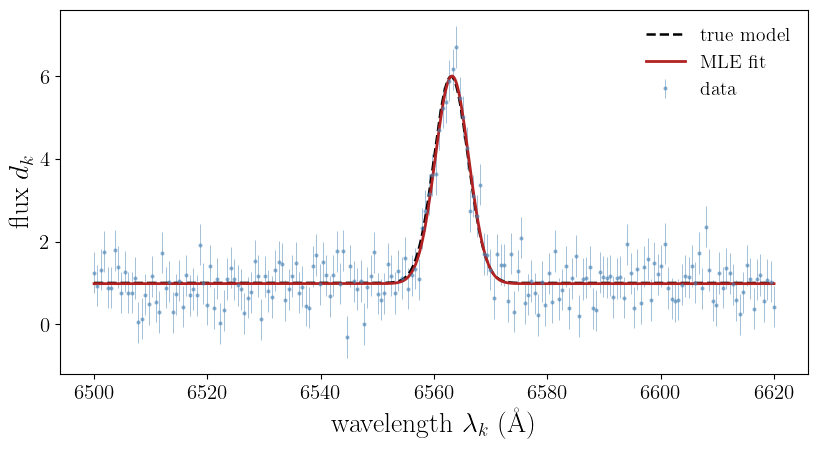

In [2]:
# Multiple starting points to verify uniqueness of the minimum
starting_points = [
    np.array([5.0, 6563.0, 3.0, 1.0]),   # close to truth
    np.array([3.0, 6560.0, 5.0, 0.5]),
    np.array([7.0, 6565.0, 2.0, 1.5]),
    np.array([4.0, 6558.0, 4.0, 0.8]),
]

results = []
for x0 in starting_points:
    res = minimize(lambda th: -logL(th), x0=x0, method='Nelder-Mead',
                   options={'xatol': 1e-9, 'fatol': 1e-9, 'maxiter': 100000})
    results.append(res)
    print(f'start {np.round(x0,1)} -> theta_hat={np.round(res.x,4)}, -L={res.fun:.4f}')

theta_hat = results[0].x
print(f'\nMLE:  A={theta_hat[0]:.4f}  mu={theta_hat[1]:.4f}  sig={theta_hat[2]:.4f}  B={theta_hat[3]:.4f}')
print(f'True: A={theta_true[0]:.4f}  mu={theta_true[1]:.4f}  sig={theta_true[2]:.4f}  B={theta_true[3]:.4f}')

# Visual comparison of MLE fit and true model
lam_fine = np.linspace(lam_data.min(), lam_data.max(), 500)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.errorbar(lam_data, d_data, yerr=sigma_n, fmt='.', color='steelblue',
            alpha=0.5, markersize=4, linewidth=0.7, label='data')
ax.plot(lam_fine, model(lam_fine, theta_true), 'k--', lw=1.8, label='true model')
ax.plot(lam_fine, model(lam_fine, theta_hat), color='firebrick', lw=2.0, label='MLE fit')
ax.set_xlabel(r'wavelength $\lambda_k$ (\AA)', fontsize=fontsi2)
ax.set_ylabel(r'flux $d_k$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(frameon=False, fontsize=fontsi - 1)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.16, top=0.97)
plt.savefig('./sheet3_output/emission_line_fit.pdf')
plt.show()

**c.** Implement the score $s_\alpha(\theta)=\partial_\alpha\mathcal{L}(\theta)$ analytically, then as forward and central finite differences, and compare them at $\hat\theta_\mathrm{MLE}$.

In [3]:
def score_exact(theta, lam=lam_data, d=d_data, sn=sigma_n):
    """Analytical score vector dL/d theta = (1/sn^2) sum_k resid_k * d m_k / d theta."""
    A, mu, sig, B = theta
    r = (lam - mu) / sig
    g = np.exp(-0.5 * r**2)
    resid = d - model(lam, theta)
    dLdA   = np.sum(resid * g)              / sn**2
    dLdmu  = np.sum(resid * A * g * r / sig) / sn**2
    dLdsig = np.sum(resid * A * g * r**2 / sig) / sn**2
    dLdB   = np.sum(resid)                  / sn**2
    return np.array([dLdA, dLdmu, dLdsig, dLdB])

def score_fwd(theta, h, lam=lam_data, d=d_data, sn=sigma_n):
    """Forward-difference numerical score."""
    s, L0 = np.zeros(len(theta)), logL(theta, lam, d, sn)
    for a in range(len(theta)):
        th_p = theta.copy(); th_p[a] += h
        s[a] = (logL(th_p, lam, d, sn) - L0) / h
    return s

def score_cen(theta, h, lam=lam_data, d=d_data, sn=sigma_n):
    """Central-difference numerical score."""
    s = np.zeros(len(theta))
    for a in range(len(theta)):
        th_p = theta.copy(); th_p[a] += h
        th_m = theta.copy(); th_m[a] -= h
        s[a] = (logL(th_p, lam, d, sn) - logL(th_m, lam, d, sn)) / (2*h)
    return s

# Verify: score should vanish at the MLE
s_mle = score_exact(theta_hat)
print('Exact score at MLE (should be ~0):', np.round(s_mle, 6))
print('Params:', param_names)

Exact score at MLE (should be ~0): [ 0.e+00  0.e+00 -0.e+00  2.e-06]
Params: ['A', 'mu', 'sigma_l', 'B']


**d.** For each parameter, plot $|s_\alpha^\mathrm{num} - s_\alpha^\mathrm{exact}|/|s_\alpha^\mathrm{exact}|$ against $h\in[10^{-12},10^{0}]$ for both schemes.  Explain the shape.

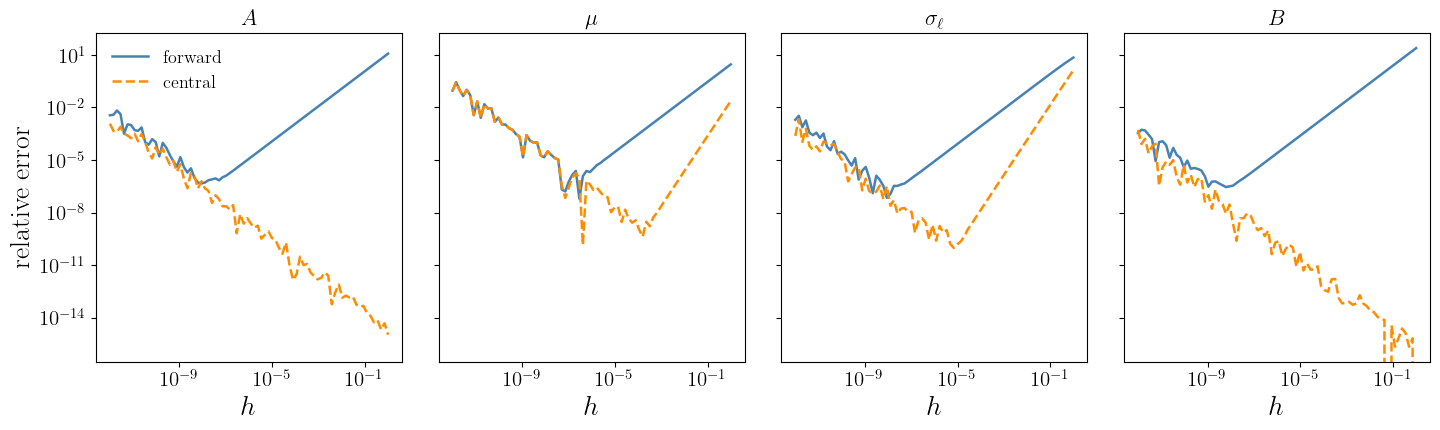

Shape: two competing errors.
  Small h  → round-off dominates (catastrophic cancellation when subtracting
             nearly-equal floats, then dividing by tiny h).
  Large h  → truncation dominates: O(h) for forward, O(h^2) for central.
  Optimal h minimises sum of both errors:
    forward:  h* ~ sqrt(eps_mach) ~ 1e-8
    central:  h* ~ eps_mach^(1/3) ~ 1e-5   (central is more accurate)



In [4]:
h_vals = np.logspace(-12, 0, 80)
# Evaluate at true theta so the exact score is non-zero and well-defined
s_ref = score_exact(theta_true)

fig, axes = plt.subplots(1, 4, figsize=(14.5, 4.5), sharey=True)

for alpha, (ax, label) in enumerate(zip(axes, param_labels)):
    err_fwd, err_cen = [], []
    for h in h_vals:
        sf = score_fwd(theta_true, h)[alpha]
        sc = score_cen(theta_true, h)[alpha]
        ref = abs(s_ref[alpha]) + 1e-30
        err_fwd.append(abs(sf - s_ref[alpha]) / ref)
        err_cen.append(abs(sc - s_ref[alpha]) / ref)
    ax.loglog(h_vals, err_fwd,  color='steelblue',  lw=1.8,        label='forward')
    ax.loglog(h_vals, err_cen,  color='darkorange', lw=1.8, ls='--', label='central')
    ax.set_xlabel(r'$h$', fontsize=fontsi2)
    ax.set_title(label, fontsize=fontsi + 1)
    ax.tick_params(labelsize=fontsi)

axes[0].set_ylabel('relative error', fontsize=fontsi2)
axes[0].legend(frameon=False, fontsize=fontsi - 2)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.2, top=0.93, wspace=0.12)
plt.savefig('./sheet3_output/score_deriv_errors.pdf')
plt.show()

# --- Explanation printed as a summary ---
print(
    "Shape: two competing errors.\n"
    "  Small h  → round-off dominates (catastrophic cancellation when subtracting\n"
    "             nearly-equal floats, then dividing by tiny h).\n"
    "  Large h  → truncation dominates: O(h) for forward, O(h^2) for central.\n"
    "  Optimal h minimises sum of both errors:\n"
    "    forward:  h* ~ sqrt(eps_mach) ~ 1e-8\n"
    "    central:  h* ~ eps_mach^(1/3) ~ 1e-5   (central is more accurate)\n"
)

**e.** Repeat for the diagonal elements of the Hessian $\partial_\alpha\partial_\alpha\mathcal{L}$.  How does the optimal $h$ shift compared to the gradient case?

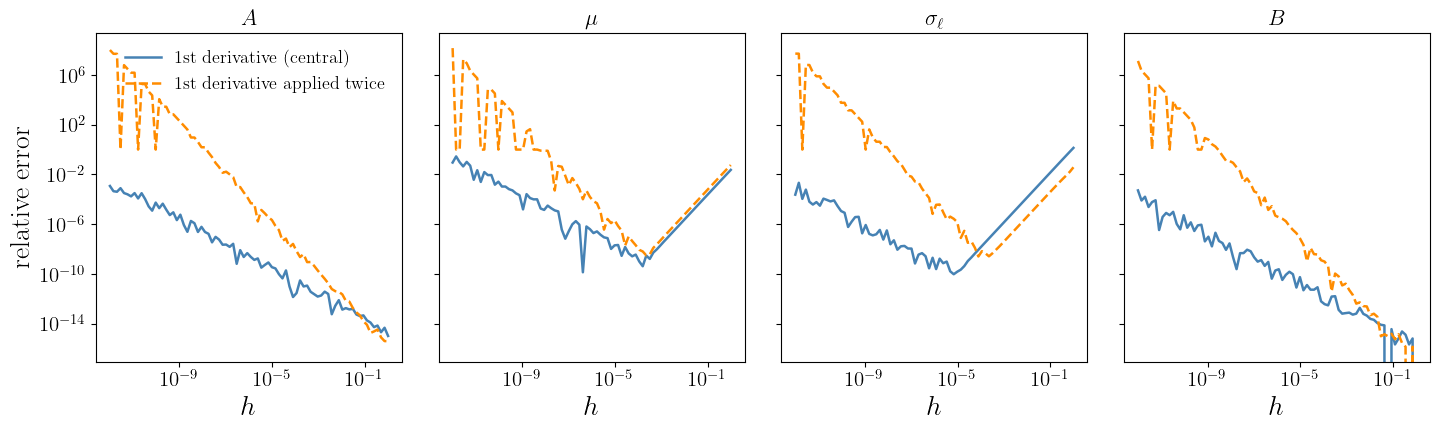

Comparison of the central first derivative with the Hessian built by applying
the same first-derivative operator twice:
  The first derivative reaches its optimum at smaller h (around 1e-5).
  Applying it twice amplifies round-off and pushes the optimal h to larger values,
  typically around 1e-4 to 1e-3.
  So the repeated-differentiation route is visibly less accurate and less stable
  than the single first-derivative estimate.



In [5]:
def hess_diag_exact(theta, lam=lam_data, d=d_data, sn=sigma_n):
    """Analytical diagonal Hessian elements d^2 L / d theta_a^2."""
    A, mu, sig, B = theta
    r = (lam - mu) / sig
    g = np.exp(-0.5 * r**2)
    resid = d - model(lam, theta)
    # d^2m/dA^2 = 0  =>  d^2L/dA^2 = -(1/sn^2) sum g^2
    H_AA = -np.sum(g**2) / sn**2
    # d^2L/dmu^2: product-rule; dm/dmu = A g r/sig; d^2m/dmu^2 = A g (r^2-1)/sig^2
    H_mumu = (np.sum(resid * A * g * (r**2 - 1) / sig**2)
              - np.sum((A * g * r / sig)**2)) / sn**2
    # d^2L/dsig^2: dm/dsig = A g r^2/sig; d^2m/dsig^2 = A g r^2(r^2-3)/sig^2
    H_ss = (np.sum(resid * A * g * r**2 * (r**2 - 3) / sig**2)
            - np.sum((A * g * r**2 / sig)**2)) / sn**2
    # d^2L/dB^2 = -(1/sn^2) * M
    H_BB = -len(lam) / sn**2
    return np.array([H_AA, H_mumu, H_ss, H_BB])

def hess_diag_via_score(theta, h, lam=lam_data, d=d_data, sn=sigma_n):
    """Apply the central first-derivative operator twice.

    For each parameter a, first compute the numerical score component s_a
    with score_cen, then differentiate that score component once more
    in the same direction using another central difference.
    """
    H = np.zeros(len(theta))
    for a in range(len(theta)):
        th_p = theta.copy(); th_p[a] += h
        th_m = theta.copy(); th_m[a] -= h
        s_p = score_cen(th_p, h, lam, d, sn)[a]
        s_m = score_cen(th_m, h, lam, d, sn)[a]
        H[a] = (s_p - s_m) / (2 * h)
    return H

H_ref = hess_diag_exact(theta_true)
s_ref = score_exact(theta_true)

fig, axes = plt.subplots(1, 4, figsize=(14.5, 4.5), sharey=True)
for alpha, (ax, label) in enumerate(zip(axes, param_labels)):
    errs_grad = []
    errs_twice = []
    for h in h_vals:
        s_central = score_cen(theta_true, h)[alpha]
        H_twice = hess_diag_via_score(theta_true, h)[alpha]
        ref_grad = abs(s_ref[alpha]) + 1e-30
        ref_hess = abs(H_ref[alpha]) + 1e-30
        errs_grad.append(abs(s_central - s_ref[alpha]) / ref_grad)
        errs_twice.append(abs(H_twice - H_ref[alpha]) / ref_hess)
    ax.loglog(h_vals, errs_grad, color='steelblue', lw=1.8,
              label='1st derivative (central)')
    ax.loglog(h_vals, errs_twice, color='darkorange', lw=1.8, ls='--',
              label='1st derivative applied twice')
    ax.set_xlabel(r'$h$', fontsize=fontsi2)
    ax.set_title(label, fontsize=fontsi + 1)
    ax.tick_params(labelsize=fontsi)

axes[0].set_ylabel('relative error', fontsize=fontsi2)
axes[0].legend(frameon=False, fontsize=fontsi - 2)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.2, top=0.93, wspace=0.12)
plt.savefig('./sheet3_output/hessian_diag_errors.pdf')
plt.show()

print(
    "Comparison of the central first derivative with the Hessian built by applying\n"
    "the same first-derivative operator twice:\n"
    "  The first derivative reaches its optimum at smaller h (around 1e-5).\n"
    "  Applying it twice amplifies round-off and pushes the optimal h to larger values,\n"
    "  typically around 1e-4 to 1e-3.\n"
    "  So the repeated-differentiation route is visibly less accurate and less stable\n"
    "  than the single first-derivative estimate.\n"
 )

**f.** Estimate the parameter covariance matrix from the Hessian of $-\mathcal{L}$ at $\hat\theta_\mathrm{MLE}$ numerically and report the uncertainty for each parameter, $\sigma_{\hat\theta_\mathrm{MLE}}$.

     Param     theta_hat     sigma_hat
----------------------------------------
         A       5.02919       0.21287
        mu    6563.17157       0.14086
   sigma_l       2.94896       0.15186
         B       0.98313       0.03800


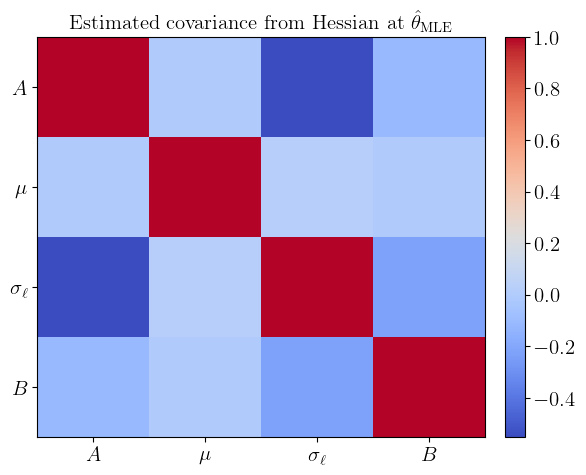

In [6]:
def fisher_hessian(theta, h=1e-4, lam=lam_data, d=d_data, sn=sigma_n):
    """Full Fisher matrix via 4-point mixed central differences (off-diag) and
    3-point formula (diagonal). F = -H where H_ab = d^2 L / d theta_a d theta_b."""
    npar = len(theta)
    F = np.zeros((npar, npar))
    L0 = logL(theta, lam, d, sn)
    for a in range(npar):
        # Diagonal second derivative.
        th_p = theta.copy(); th_p[a] += h
        th_m = theta.copy(); th_m[a] -= h
        F[a, a] = -(logL(th_p, lam, d, sn) - 2 * L0 + logL(th_m, lam, d, sn)) / h**2

        # Mixed second derivatives.
        for b in range(a + 1, npar):
            th_pp = theta.copy(); th_pp[a] += h; th_pp[b] += h
            th_pm = theta.copy(); th_pm[a] += h; th_pm[b] -= h
            th_mp = theta.copy(); th_mp[a] -= h; th_mp[b] += h
            th_mm = theta.copy(); th_mm[a] -= h; th_mm[b] -= h
            H_ab = (
                logL(th_pp, lam, d, sn) - logL(th_pm, lam, d, sn)
                - logL(th_mp, lam, d, sn) + logL(th_mm, lam, d, sn)
            ) / (4 * h**2)
            F[a, b] = F[b, a] = -H_ab
    return F


# Covariance estimate from numerical Hessian/Fisher at the MLE.
F_hat = fisher_hessian(theta_hat)
Cov_hat = np.linalg.inv(F_hat)
sigma_hat = np.sqrt(np.diag(Cov_hat))

print(f"{'Param':>10}  {'theta_hat':>12}  {'sigma_hat':>12}")
print('-' * 40)
for pn, th, sh in zip(param_names, theta_hat, sigma_hat):
    print(f'{pn:>10}  {th:>12.5f}  {sh:>12.5f}')

# Visualize covariance structure.
fig, ax = plt.subplots(figsize=(6.2, 5.0))
im = ax.imshow(Cov_hat/np.outer(sigma_hat, sigma_hat), cmap='coolwarm', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(4))
ax.set_xticklabels(param_labels, fontsize=fontsi)
ax.set_yticks(range(4))
ax.set_yticklabels(param_labels, fontsize=fontsi)
ax.set_title(r'Estimated covariance from Hessian at $\hat\theta_{\mathrm{MLE}}$', fontsize=fontsi)
fig.subplots_adjust(left=0.16, right=0.95, bottom=0.12, top=0.92)
plt.savefig('./sheet3_output/mle_covariance_hessian.pdf')
plt.show()

**g.** Set $\sigma_n=5$ so amplitude $A$ and continuum $B$ are poorly constrained (low-SNR regime). Compute the full Fisher matrix via finite differences and compare element-by-element to the analytical result. What do you observe?

In [7]:
sigma_n_low = 5.0

# Analytical Fisher in low-SNR regime.
F_ana_low = fisher_analytical(theta_true, sn=sigma_n_low)

# Compare several finite-difference step sizes.
h_scan = np.logspace(-10, -2, 5)
diag_rel_err_by_h = []

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

# Left panel: analytical Fisher reference.
im = axes[0].imshow(F_ana_low/np.outer(np.sqrt(np.diag(F_ana_low)), np.sqrt(np.diag(F_ana_low))), cmap='coolwarm', aspect='auto')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(param_labels, fontsize=fontsi)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(param_labels, fontsize=fontsi)
axes[0].set_title(r'Analytical Fisher ($\sigma_n=5$)', fontsize=fontsi)

# Right panel: diagonal relative errors versus parameter index.
for h in h_scan:
    F_num_low = fisher_hessian(theta_true, h=h, lam=lam_data, d=d_data, sn=sigma_n_low)
    rel_err = np.abs(F_num_low - F_ana_low) / (np.abs(F_ana_low) + 1e-30)
    diag_rel_err = np.diag(rel_err)
    diag_rel_err_by_h.append(diag_rel_err)
    axes[1].semilogy(range(4), diag_rel_err, marker='o', lw=1.8, label=rf'$h={h:.0e}$')

axes[1].set_xlabel('Parameter', fontsize=fontsi)
axes[1].set_ylabel('Relative error', fontsize=fontsi)
axes[1].set_title('Diagonal relative error for several $h$', fontsize=fontsi)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(param_labels, fontsize=fontsi)
axes[1].tick_params(labelsize=fontsi)
axes[1].legend(frameon=False, fontsize=fontsi - 3)

fig.subplots_adjust(left=0.07, right=0.98, bottom=0.12, top=0.92, wspace=0.30)
plt.savefig('./sheet3_output/fisher_low_snr.pdf')
plt.show()

print('Analytical Fisher (low SNR):')
print(np.round(F_ana_low, 4))
print('\nDiagonal relative error by parameter for each h:')
for h, diag_rel_err in zip(h_scan, diag_rel_err_by_h):
    print(f'\nh = {h:.0e}')
    for name, err in zip(param_names, diag_rel_err):
        print(f'  {name}: {err:.4f}')

# Short interpretation focused on low-SNR behavior.
best_idx = int(np.argmin(np.mean(np.array(diag_rel_err_by_h), axis=1)))
best_diag = diag_rel_err_by_h[best_idx]

print('\nObservation:')
print('  In low SNR, Fisher entries involving A and B are the least stable numerically.')
print('  Their curvature is weak (small likelihood second derivatives), so finite differences')
print('  become more sensitive to subtraction noise and step-size choice.')
print(f"  Best tested step here is h = {h_scan[best_idx]:.0e}, with diagonal relative errors:")
for name, err in zip(param_names, best_diag):
    print(f'    {name}: {err:.4f}')

NameError: name 'fisher_analytical' is not defined

# 3.3 Questions

**1. Why do we work with the log-likelihood rather than the likelihood directly?**

Because products of many probabilities become tiny and numerically unstable, while logs turn products into sums. This is more stable and easier to differentiate. The maximiser is unchanged since the log is monotonic.

**2. The likelihood function is not a probability distribution over the parameters. What does it represent, and why does this matter?**

For fixed data, $\mathcal{L}(\theta)=p(d\mid\theta)$ is a function of $\theta$ that scores parameter values by how compatible they are with the observed data. It is not normalised in $\theta$ and does not itself encode parameter uncertainty unless you add prior information (Bayesian) or asymptotic approximations (frequentist).

**3. The score function has zero expectation at the true parameters. What does this mean intuitively, and does it vanish for any single dataset?**

Intuitively, at the true parameter there is no systematic direction in which the likelihood wants to increase, averaged over repeated datasets:
$\mathbb{E}[s(\theta_0)] = 0.$
For one finite dataset, the score is generally not exactly zero (except at the sample MLE by construction).

**4. The MLE for the variance of a Gaussian uses a factor of $1/n$ rather than $1/(n-1)$. What does this tell us about MLE in general?**

MLE prioritises maximising likelihood, not unbiasedness. So finite-sample bias can occur (variance MLE is biased low), even though MLEs are typically consistent and asymptotically efficient.

**5. What is the Fisher information, and why does it have two equivalent definitions?**

Fisher information measures local curvature/sensitivity of the log-likelihood and therefore how precisely parameters can be estimated:
$$F(\theta)=\mathbb{E}[s(\theta)s(\theta)^\top] = -\mathbb{E}[\nabla_\theta^2 \mathcal{L}(\theta)].$$
The equivalence follows from regularity conditions that permit exchanging derivatives and expectation.

**6. Why does Fisher information add for independent observations, and what is the practical implication?**

For independent data, log-likelihoods add, so both scores and expected curvature contributions add:
$F_{\text{total}} = \sum_i F_i.$
Practically, more independent data increases information roughly linearly, so parameter uncertainties scale like $1/\sqrt{N}$ in regular problems.